In [ ]:
#============================================================
# Generate chaotic Rössler system data
# Rows = x1..x7, y1..y7, z1..z7
# Columns = samples from perturbed initial conditions
#============================================================

import numpy as np
import pandas as pd
from scipy.integrate import solve_ivp

# ========================
# PARAMETERS
# ========================
num_samples = 2000      # number of samples (perturbed initial conditions)
T = 7                   # number of timepoints to save
t_total = 120           # total integration time
a, b, c = 0.2, 0.2, 5.7  # classic chaotic Rössler parameters
transient_time = 70     # discard first 70 units to avoid transients
t_eval = np.linspace(transient_time, t_total, T)  # 7 equidistant timepoints after transient

# ========================
# Base initial condition (chaotic regime)
# ========================
base_x0 = np.array([0.1, 0.0, 0.0])
perturb_scale = 1e-3  # small perturbation for samples

# ========================
# Rössler system
# ========================
def rossler(t, X):
    dx = -X[1] - X[2]
    dy = X[0] + a*X[1]
    dz = b + X[2]*(X[0] - c)
    return [dx, dy, dz]

# ========================
# Generate data
# ========================
data = np.zeros((3*T, num_samples))  # 21 rows (x1..x7, y1..y7, z1..z7), columns = samples

for s in range(num_samples):
    # Slightly perturb initial condition
    x0 = base_x0 + np.random.normal(0, perturb_scale, size=3)
    sol = solve_ivp(rossler, (0, t_total), x0, t_eval=t_eval,
                    rtol=1e-9, atol=1e-12)
    
    # Fill rows
    data[0:T, s] = sol.y[0, :]      # x1..x7
    data[T:2*T, s] = sol.y[1, :]    # y1..y7
    data[2*T:3*T, s] = sol.y[2, :]  # z1..z7

# ========================
# Save to CSV
# ========================
df = pd.DataFrame(data)
csv_file = "rossler_chaotic_data.csv"
df.to_csv(csv_file, index=False)

print(f"Rössler chaotic data saved to {csv_file}")
print("Data shape (rows x samples):", data.shape)


In [1]:
# ============================================================
# DynML for Rössler chaotic direct-transition prediction
# Loads saved Rössler data and evaluates:
#   1. DynML
#   2. Persistence baseline
#   3. Direct ridge regression baseline
#
# Reviewer-oriented updates:
#   - train-only scaling to avoid data leakage
#   - RMSE, MAE, R2, Pearson r
#   - multiple random seeds
#   - baseline comparisons
#   - updated manuscript figure for one representative seed
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from scipy.integrate import solve_ivp
from scipy.stats import pearsonr
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge


# ============================================================
# User settings
# ============================================================

DATA_FILE = Path("rossler_chaotic_data.csv")

T = 7
NUM_VARS = 3  # x, y, z

# DynML reservoir settings
N = 30
T_INITIAL = 0.0
T_FINAL = 30.0

PARAM_RANGE_RESERVOIR = [
    (9.9, 10.1),    # sigma
    (27.9, 28.1),  # rho
    (2.65, 2.70)   # beta
]
TAU_RANGE = (1.0, 8.0)

# Evaluation settings
TEST_SIZE = 0.20
SEEDS = [17, 42, 101, 202, 303]

# Direct ridge baseline
RIDGE_ALPHA = 1e-6

# Output files
METRICS_BY_SEED_FILE = "rossler_direct_transition_metrics_by_seed.csv"
METRICS_SUMMARY_FILE = "rossler_direct_transition_metrics_summary.csv"
METRICS_BY_TRANSITION_FILE = "rossler_direct_transition_metrics_by_transition_seed42.csv"

FIGURE_JPEG = "lorenz_maps_rossler_updated.jpeg"
FIGURE_PDF = "lorenz_maps_rossler_updated.pdf"


# ============================================================
# Utility functions
# ============================================================

def compute_metrics(y_true, y_pred):
    """
    Compute Pearson r, RMSE, MAE, and R2 for flattened arrays.
    """
    y_true = np.asarray(y_true).reshape(-1)
    y_pred = np.asarray(y_pred).reshape(-1)

    rmse = np.sqrt(np.mean((y_pred - y_true) ** 2))
    mae = np.mean(np.abs(y_pred - y_true))

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan

    if np.std(y_true) > 0 and np.std(y_pred) > 0:
        r, p = pearsonr(y_true, y_pred)
    else:
        r, p = np.nan, np.nan

    return {
        "pearson_r": r,
        "pearson_p": p,
        "rmse": rmse,
        "mae": mae,
        "r2": r2
    }


def lorenz_system(t, X, params, N):
    """
    Vectorized Lorenz reservoir.
    params columns: sigma, rho, beta, tau.
    """
    X = X.reshape(N, 3)

    sigma = params[:, 0]
    rho = params[:, 1]
    beta = params[:, 2]
    tau = params[:, 3]

    dxdt = sigma * (X[:, 1] - X[:, 0]) / tau
    dydt = (X[:, 0] * (rho - X[:, 2]) - X[:, 1]) / tau
    dzdt = (X[:, 0] * X[:, 1] - beta * X[:, 2]) / tau

    return np.stack([dxdt, dydt, dzdt], axis=1).reshape(-1)


def compute_dynml_reservoir_states(X_norm, seed):
    """
    Compute final reservoir states for all samples.
    X_norm shape: input_dim x num_samples.
    Returns phi shape: 3N x num_samples.
    """
    rng = np.random.default_rng(seed)

    M = X_norm.shape[0]
    D = X_norm.shape[1]

    reservoir_params = np.array([
        [
            rng.uniform(PARAM_RANGE_RESERVOIR[0][0], PARAM_RANGE_RESERVOIR[0][1]),
            rng.uniform(PARAM_RANGE_RESERVOIR[1][0], PARAM_RANGE_RESERVOIR[1][1]),
            rng.uniform(PARAM_RANGE_RESERVOIR[2][0], PARAM_RANGE_RESERVOIR[2][1]),
            rng.uniform(TAU_RANGE[0], TAU_RANGE[1])
        ]
        for _ in range(N)
    ])

    R = rng.uniform(-1.0, 1.0, size=(3 * N, M))

    phi = np.zeros((3 * N, D))

    for i in range(D):
        initial_state = R @ X_norm[:, i]

        sol = solve_ivp(
            lorenz_system,
            (T_INITIAL, T_FINAL),
            initial_state,
            t_eval=[T_FINAL],
            args=(reservoir_params, N),
            rtol=1e-6,
            atol=1e-9
        )

        if not sol.success:
            raise RuntimeError(f"Lorenz reservoir integration failed for sample {i}: {sol.message}")

        phi[:, i] = sol.y[:, -1]

    return phi


def fit_ols_readout(phi_train, Y_train):
    """
    Fit ordinary least-squares readout.
    phi_train shape: num_train x reservoir_dim
    Y_train shape: num_train x output_dim
    Returns S with shape output_dim x reservoir_dim.
    """
    S_T, residuals, rank, svals = np.linalg.lstsq(phi_train, Y_train, rcond=None)
    S = S_T.T
    return S


def make_input_output_pairs(expr):
    """
    Original organization:
        rows = x1..x7, y1..y7, z1..z7
        columns = samples

    Returns:
        X shape = 18 x samples = x1..x6, y1..y6, z1..z6
        Y shape = 18 x samples = x2..x7, y2..y7, z2..z7
    """
    X = []
    Y = []

    for g in range(NUM_VARS):
        block = expr[g * T:(g + 1) * T, :]
        for t in range(T - 1):
            X.append(block[t, :])
            Y.append(block[t + 1, :])

    X = np.asarray(X)
    Y = np.asarray(Y)

    return X, Y


def transition_name(row_index):
    """
    Convert output row index to variable and transition label.
    Row order is:
        x t1->t2 ... x t6->t7,
        y t1->t2 ... y t6->t7,
        z t1->t2 ... z t6->t7.
    """
    transition_count = T - 1
    var_names = ["x", "y", "z"]

    var_index = row_index // transition_count
    transition_index = row_index % transition_count

    return var_names[var_index], f"t{transition_index + 1}->t{transition_index + 2}"


# ============================================================
# Load data
# ============================================================

if not DATA_FILE.exists():
    raise FileNotFoundError(f"Could not find {DATA_FILE}")

df = pd.read_csv(DATA_FILE)
expr = df.values

expected_rows = NUM_VARS * T
if expr.shape[0] != expected_rows:
    raise ValueError(f"Expected {expected_rows} rows, found {expr.shape[0]} rows.")

if not np.all(np.isfinite(expr)):
    raise ValueError("Input data contain NaN or infinite values.")

num_samples = expr.shape[1]

print("Loaded Rössler data")
print("-------------------")
print("Data shape:", expr.shape)
print("Variables:", NUM_VARS)
print("Timepoints:", T)
print("Samples:", num_samples)

X, Y = make_input_output_pairs(expr)

M = X.shape[0]
P = Y.shape[0]
D = X.shape[1]

print()
print("Input-output construction")
print("-------------------------")
print("X shape:", X.shape)
print("Y shape:", Y.shape)
print("Input dimension:", M)
print("Output dimension:", P)
print("Samples:", D)


# ============================================================
# Main evaluation across seeds
# ============================================================

all_seed_metrics = []
representative_results = None

for seed in SEEDS:
    print()
    print(f"Running seed {seed}")
    print("----------------")

    sample_indices = np.arange(D)

    train_idx, test_idx = train_test_split(
        sample_indices,
        test_size=TEST_SIZE,
        random_state=seed
    )

    # --------------------------------------------------------
    # Train-only scaling
    # --------------------------------------------------------
    scaler_in = StandardScaler()
    scaler_out = StandardScaler()

    X_train_raw = X[:, train_idx].T
    X_test_raw = X[:, test_idx].T

    Y_train_raw = Y[:, train_idx].T
    Y_test_raw = Y[:, test_idx].T

    X_train_norm = scaler_in.fit_transform(X_train_raw).T
    X_test_norm = scaler_in.transform(X_test_raw).T

    Y_train_norm = scaler_out.fit_transform(Y_train_raw).T
    Y_test_norm = scaler_out.transform(Y_test_raw).T

    # Also build all normalized X for reservoir integration
    X_all_norm = np.zeros_like(X, dtype=float)
    X_all_norm[:, train_idx] = X_train_norm
    X_all_norm[:, test_idx] = X_test_norm

    # --------------------------------------------------------
    # DynML reservoir states
    # --------------------------------------------------------
    phi = compute_dynml_reservoir_states(X_all_norm, seed=seed)

    phi_train = phi[:, train_idx].T
    phi_test = phi[:, test_idx].T

    # --------------------------------------------------------
    # DynML OLS readout
    # --------------------------------------------------------
    S = fit_ols_readout(phi_train, Y_train_norm.T)

    dynml_train_norm = S @ phi[:, train_idx]
    dynml_test_norm = S @ phi[:, test_idx]

    dynml_train = scaler_out.inverse_transform(dynml_train_norm.T).T
    dynml_test = scaler_out.inverse_transform(dynml_test_norm.T).T

    Y_train_true = Y[:, train_idx]
    Y_test_true = Y[:, test_idx]

    # --------------------------------------------------------
    # Persistence baseline: predict next sampled state as current sampled state
    # Since X rows and Y rows are aligned transition-wise, persistence is Y_hat = X.
    # --------------------------------------------------------
    persist_train = X[:, train_idx]
    persist_test = X[:, test_idx]

    # --------------------------------------------------------
    # Direct ridge regression baseline: Y from X directly
    # Fit on normalized training data, predict test, inverse-transform output.
    # --------------------------------------------------------
    ridge = Ridge(alpha=RIDGE_ALPHA)
    ridge.fit(X_train_norm.T, Y_train_norm.T)

    ridge_train_norm = ridge.predict(X_train_norm.T).T
    ridge_test_norm = ridge.predict(X_test_norm.T).T

    ridge_train = scaler_out.inverse_transform(ridge_train_norm.T).T
    ridge_test = scaler_out.inverse_transform(ridge_test_norm.T).T

    # --------------------------------------------------------
    # Aggregate metrics
    # --------------------------------------------------------
    model_predictions = {
        "DynML": (dynml_train, dynml_test),
        "Persistence": (persist_train, persist_test),
        "Direct ridge": (ridge_train, ridge_test)
    }

    for model_name, (pred_train, pred_test) in model_predictions.items():
        train_metrics = compute_metrics(Y_train_true, pred_train)
        test_metrics = compute_metrics(Y_test_true, pred_test)

        row_train = {
            "seed": seed,
            "model": model_name,
            "split": "train",
            **train_metrics
        }

        row_test = {
            "seed": seed,
            "model": model_name,
            "split": "test",
            **test_metrics
        }

        all_seed_metrics.append(row_train)
        all_seed_metrics.append(row_test)

    print("Test metrics")
    for model_name, (pred_train, pred_test) in model_predictions.items():
        m = compute_metrics(Y_test_true, pred_test)
        print(
            f"{model_name:12s} "
            f"r={m['pearson_r']:.4f}, "
            f"RMSE={m['rmse']:.4f}, "
            f"MAE={m['mae']:.4f}, "
            f"R2={m['r2']:.4f}"
        )

    # Save one representative seed for manuscript figure
    if seed == 42:
        representative_results = {
            "seed": seed,
            "train_idx": train_idx,
            "test_idx": test_idx,
            "Y_train_true": Y_train_true,
            "Y_test_true": Y_test_true,
            "dynml_train": dynml_train,
            "dynml_test": dynml_test,
            "ridge_train": ridge_train,
            "ridge_test": ridge_test,
            "persist_train": persist_train,
            "persist_test": persist_test
        }


# ============================================================
# Save aggregate metrics
# ============================================================

metrics_df = pd.DataFrame(all_seed_metrics)
metrics_df.to_csv(METRICS_BY_SEED_FILE, index=False)

summary_df = (
    metrics_df
    .groupby(["model", "split"])
    .agg(
        pearson_r_mean=("pearson_r", "mean"),
        pearson_r_std=("pearson_r", "std"),
        rmse_mean=("rmse", "mean"),
        rmse_std=("rmse", "std"),
        mae_mean=("mae", "mean"),
        mae_std=("mae", "std"),
        r2_mean=("r2", "mean"),
        r2_std=("r2", "std")
    )
    .reset_index()
)

summary_df.to_csv(METRICS_SUMMARY_FILE, index=False)

print()
print("Saved metrics")
print("-------------")
print(METRICS_BY_SEED_FILE)
print(METRICS_SUMMARY_FILE)
print()
print(summary_df)


# ============================================================
# Per-transition metrics for representative seed
# ============================================================

if representative_results is None:
    raise RuntimeError("Representative seed 42 was not included in SEEDS.")

Y_train_true = representative_results["Y_train_true"]
Y_test_true = representative_results["Y_test_true"]
dynml_train = representative_results["dynml_train"]
dynml_test = representative_results["dynml_test"]

by_transition_rows = []

for row_index in range(P):
    var_name, trans_label = transition_name(row_index)

    train_metrics = compute_metrics(Y_train_true[row_index, :], dynml_train[row_index, :])
    test_metrics = compute_metrics(Y_test_true[row_index, :], dynml_test[row_index, :])

    by_transition_rows.append({
        "seed": 42,
        "model": "DynML",
        "split": "train",
        "variable": var_name,
        "transition": trans_label,
        **train_metrics
    })

    by_transition_rows.append({
        "seed": 42,
        "model": "DynML",
        "split": "test",
        "variable": var_name,
        "transition": trans_label,
        **test_metrics
    })

by_transition_df = pd.DataFrame(by_transition_rows)
by_transition_df.to_csv(METRICS_BY_TRANSITION_FILE, index=False)

print()
print("Saved representative per-transition metrics")
print("-------------------------------------------")
print(METRICS_BY_TRANSITION_FILE)


/Users/halders2/.local/lib/python3.13/site-packages/pandas/core/computation/expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


Loaded Rössler data
-------------------
Data shape: (21, 2000)
Variables: 3
Timepoints: 7
Samples: 2000

Input-output construction
-------------------------
X shape: (18, 2000)
Y shape: (18, 2000)
Input dimension: 18
Output dimension: 18
Samples: 2000

Running seed 17
----------------
Test metrics
DynML        r=0.9971, RMSE=0.3307, MAE=0.1602, R2=0.9941
Persistence  r=-0.4647, RMSE=6.8357, MAE=5.3558, R2=-1.5111
Direct ridge r=0.9994, RMSE=0.1450, MAE=0.0411, R2=0.9989

Running seed 42
----------------
Test metrics
DynML        r=0.9961, RMSE=0.3813, MAE=0.1756, R2=0.9922
Persistence  r=-0.4783, RMSE=6.8711, MAE=5.3615, R2=-1.5427
Direct ridge r=0.9989, RMSE=0.2031, MAE=0.0448, R2=0.9978

Running seed 101
----------------
Test metrics
DynML        r=0.9961, RMSE=0.3807, MAE=0.1781, R2=0.9922
Persistence  r=-0.4643, RMSE=6.8105, MAE=5.3336, R2=-1.5014
Direct ridge r=0.9995, RMSE=0.1402, MAE=0.0394, R2=0.9989

Running seed 202
----------------
Test metrics
DynML        r=0.9970, RMSE=0.

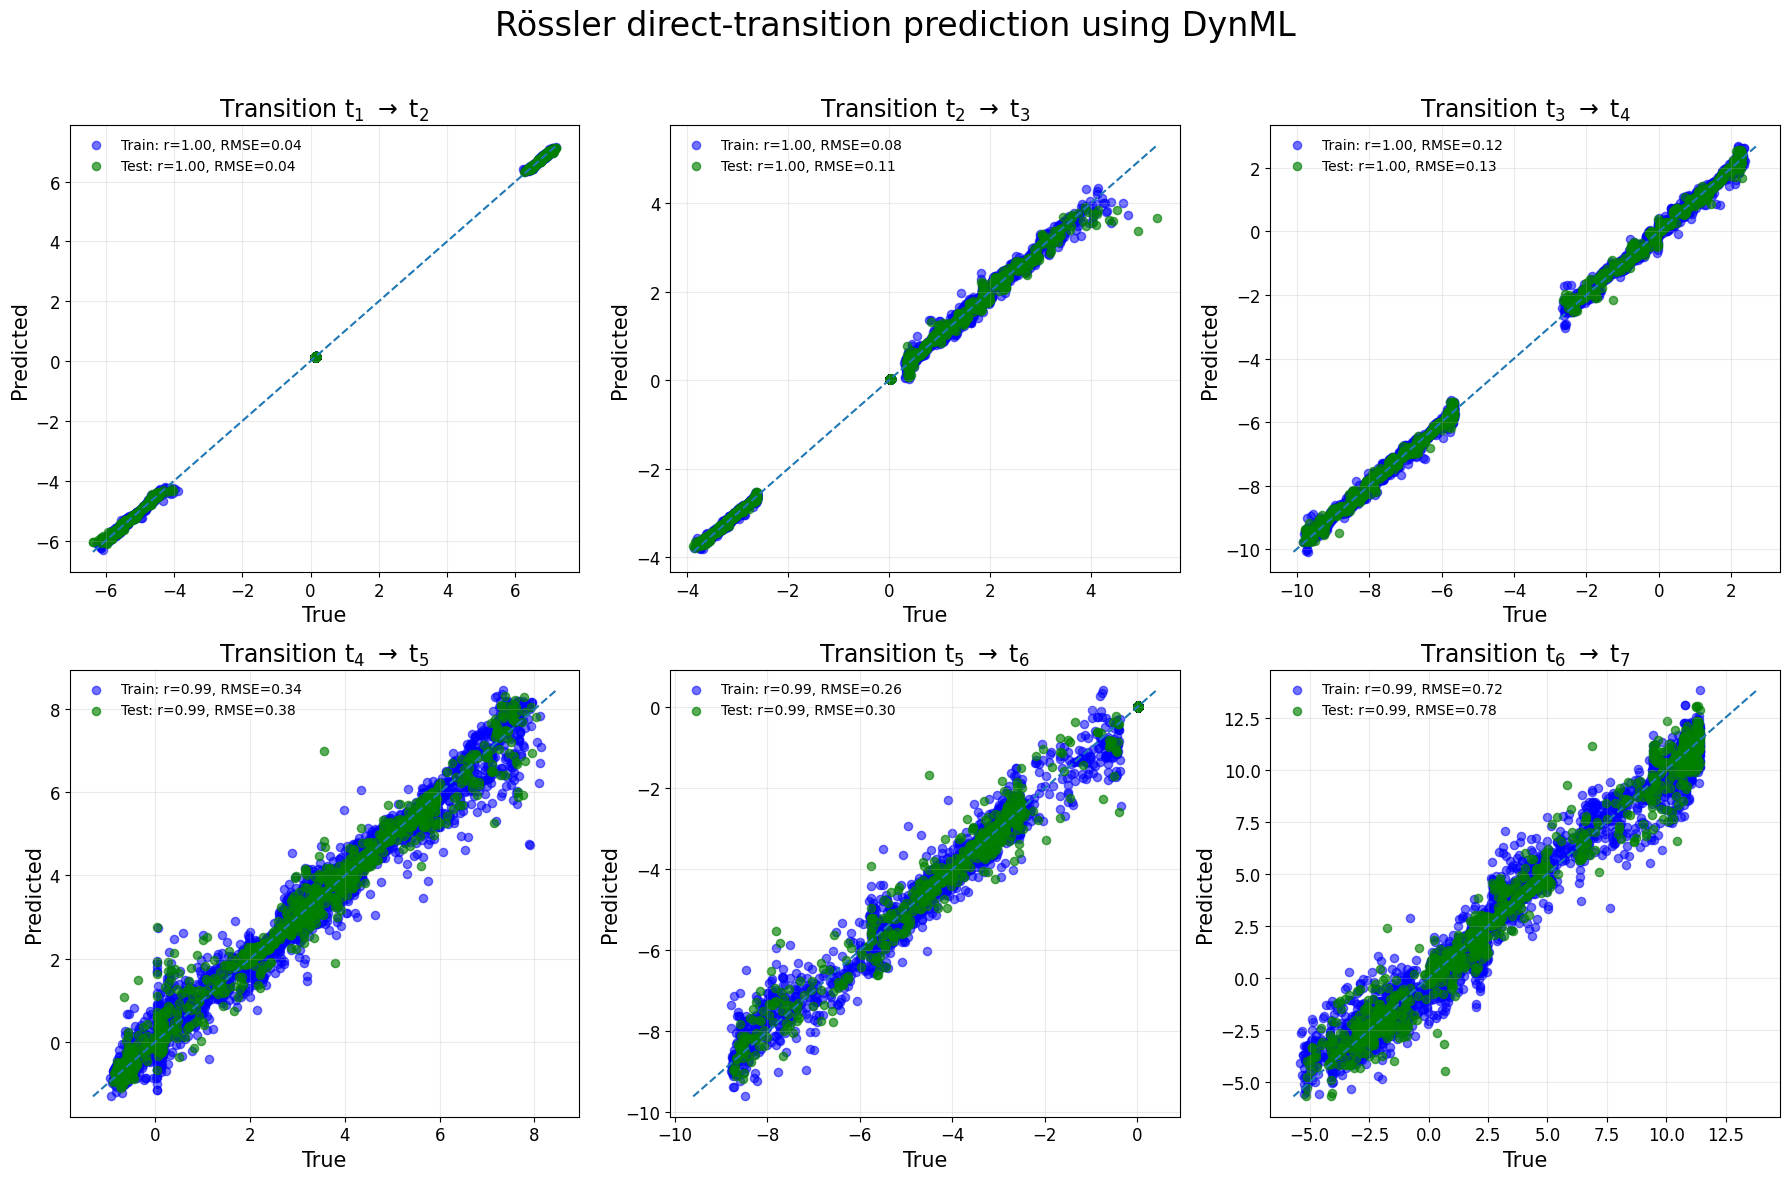


Saved manuscript figure
-----------------------
lorenz_maps_rossler_updated.jpeg
lorenz_maps_rossler_updated.pdf


In [5]:
# ============================================================
# Manuscript figure for representative seed
# Six panels: each sampled transition t_i -> t_{i+1}
# Each panel pools x, y, z for that transition.
# ============================================================

transition_count = T - 1

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for t in range(transition_count):
    ax = axes[t]

    # Rows for x/y/z for the same transition
    row_indices = [
        t,
        transition_count + t,
        2 * transition_count + t
    ]

    true_train = Y_train_true[row_indices, :]
    true_test = Y_test_true[row_indices, :]

    pred_train = dynml_train[row_indices, :]
    pred_test = dynml_test[row_indices, :]

    train_metrics = compute_metrics(true_train, pred_train)
    test_metrics = compute_metrics(true_test, pred_test)

    ax.scatter(
        true_train.flatten(),
        pred_train.flatten(),
        alpha=0.55,
        color = 'blue',
        s=35,
        label=(
            f"Train: r={train_metrics['pearson_r']:.2f}, "
            f"RMSE={train_metrics['rmse']:.2f}"
        )
    )

    ax.scatter(
        true_test.flatten(),
        pred_test.flatten(),
        alpha=0.65,
        color = 'green',
        s=35,
        label=(
            f"Test: r={test_metrics['pearson_r']:.2f}, "
            f"RMSE={test_metrics['rmse']:.2f}"
        )
    )

    mn = min(
        true_train.min(),
        true_test.min(),
        pred_train.min(),
        pred_test.min()
    )

    mx = max(
        true_train.max(),
        true_test.max(),
        pred_train.max(),
        pred_test.max()
    )

    ax.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1.5)

    ax.set_title(f"Transition t$_{t + 1}$ $\\rightarrow$ t$_{t + 2}$", fontsize=17)
    ax.set_xlabel("True", fontsize=15)
    ax.set_ylabel("Predicted", fontsize=15)
    ax.tick_params(axis="both", which="major", labelsize=12)
    ax.grid(True, alpha=0.25)
    ax.legend(fontsize=10, frameon=False)

plt.suptitle(
    "Rössler direct-transition prediction using DynML",
    fontsize=24
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.savefig(FIGURE_JPEG, format="jpeg", dpi=650, bbox_inches="tight")
plt.savefig(FIGURE_PDF, format="pdf", bbox_inches="tight")
plt.show()

print()
print("Saved manuscript figure")
print("-----------------------")
print(FIGURE_JPEG)
print(FIGURE_PDF)